<a href="https://colab.research.google.com/github/anujjakhotiya/AI-DL_2026/blob/main/Lab_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch [100/1000], Loss: 12006724730880.00
Epoch [200/1000], Loss: 9143275487232.00
Epoch [300/1000], Loss: 7670315614208.00
Epoch [400/1000], Loss: 6912603586560.00
Epoch [500/1000], Loss: 6522812235776.00
Epoch [600/1000], Loss: 6322271551488.00
Epoch [700/1000], Loss: 6219079090176.00
Epoch [800/1000], Loss: 6165962424320.00
Epoch [900/1000], Loss: 6138602979328.00
Epoch [1000/1000], Loss: 6124493340672.00

Evaluation Results
MSE: 2096680140800.0
RMSE: 1447991.761302529
MAE: 1212878.25
R2 Score: -146.37649536132812

Model Parameters
Weight: 252225.6875
Bias: 12874.8154296875


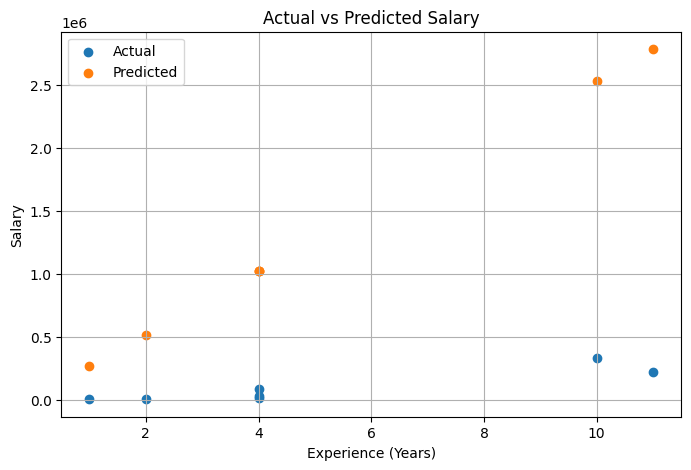

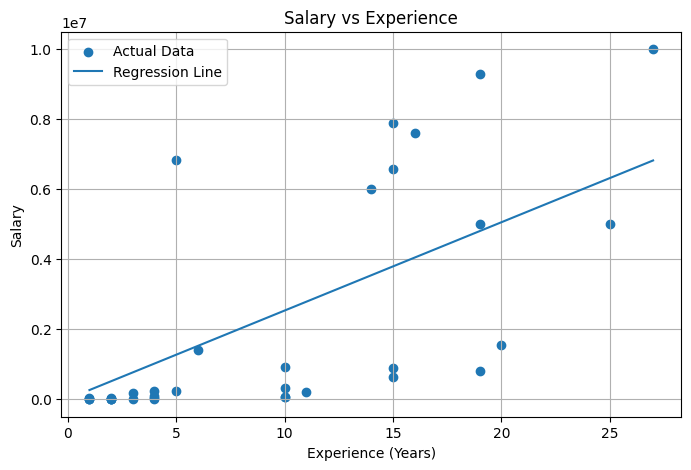

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
df = pd.read_csv("Employee_Salary_Dataset.csv")
X = df[["Experience_Years"]].values
y = df[["Salary"]].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return self.linear(x)
model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.00001)
epochs = 1000
for epoch in range(epochs):
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.2f}")
with torch.no_grad():
    y_pred = model(X_test)
y_test_np = y_test.numpy()
y_pred_np = y_pred.numpy()
mse = mean_squared_error(y_test_np, y_pred_np)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_np, y_pred_np)
r2 = r2_score(y_test_np, y_pred_np)
print("\nEvaluation Results")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("\nModel Parameters")
print("Weight:", model.linear.weight.item())
print("Bias:", model.linear.bias.item())
plt.figure(figsize=(8, 5))
plt.scatter(X_test.numpy(), y_test.numpy(), label="Actual")
plt.scatter(X_test.numpy(), y_pred.numpy(), label="Predicted")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Actual Data")
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_tensor = torch.tensor(x_line, dtype=torch.float32)
with torch.no_grad():
    y_line = model(x_tensor).numpy()
plt.plot(x_line, y_line, label="Regression Line")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.legend()
plt.grid()
plt.show()